# Classic architectures: LeNet, VGG, ResNet

### Three networks built from scratch, and the measurement each one was invented to produce

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How to write LeNet, a VGG block stack and a residual network from scratch in PyTorch. Where each one keeps its parameters, and how far each one can see. And what a skip connection does to the gradient that arrives at the first layer |
| **You should already know** | [A convolutional network, layer by layer](../02-a-cnn-layer-by-layer/) and the [size arithmetic](../01-convolution-and-pooling/) |
| **Dataset** | Fashion-MNIST, a fixed subset so the whole notebook fits in a coffee break |
| **Runtime** | A few minutes on a laptop CPU, well under one on a GPU. The device it used is printed below |
| **Next** | [08-04 Data augmentation](../04-data-augmentation/) |

---

## 1. Three answers to three different questions

It is easy to write the history of these architectures as a list of dates and
leaderboard positions, and easy to learn nothing from it. So I want to state up
front what each of the three was actually for, because that is what this
notebook measures.

**LeNet-5** (LeCun and colleagues) fixed the shape that every convolutional
network still has: alternate convolution and downsampling to build features,
then flatten and hand the result to a small stack of dense layers. Its
convolutions are 5x5, it pools by averaging, and its nonlinearity is `tanh`.

**VGG** (Simonyan and Zisserman) asked what happens if you throw away kernel
size as a design choice. Every convolution is 3x3, every pool halves the map,
and depth is the only dial left. The claim underneath is arithmetic rather than
empirical: a stack of small kernels reaches as far as one large kernel, carries
fewer weights, and puts a nonlinearity between each step.

**ResNet** (He and colleagues) was a response to a failure. Once VGG-style
stacking got deep enough, adding layers stopped helping and then started
hurting, on the **training** set, which rules out overfitting as the
explanation. A deeper network can always copy a shallower one and set the extra
layers to the identity, so it cannot have a worse best case. It simply could not
be optimised into that solution. The skip connection is a change of coordinates
that makes the identity the easy thing to learn instead of the hard thing.

Reciting that is cheap. What I want out of this chapter is three numbers.

1. What VGG's shape costs in parameters, and where those parameters sit.
2. How far each network can see, computed from the layer list rather than
   guessed.
3. What actually happens to the gradient at the first layer as a stack gets
   deeper, with and without a skip connection.

Everything trains on a fixed subset of Fashion-MNIST with identical settings.
The accuracies below are therefore lower than [08-02](../02-a-cnn-layer-by-layer/)
reports on the full training set, and they are only comparable to each other.

In [1]:
import sys
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"

N_TRAIN = 8_000        # training subset, chosen to keep the whole notebook short
BATCH = 128
EPOCHS = 5
LR = 1e-3              # Adam, the same for every model, so nothing is tuned per architecture

CLASSES = ["T-shirt", "trouser", "pullover", "dress", "coat",
           "sandal", "shirt", "sneaker", "bag", "boot"]

NOTEBOOK_STARTED = time.perf_counter()
print(f"torch {torch.__version__} on {device}")
if device == "cuda":
    print(f"gpu: {torch.cuda.get_device_name(0)}")


def sync():
    """Wait for the GPU before reading a clock. A no-op on CPU."""
    if device == "cuda":
        torch.cuda.synchronize()

torch 2.11.0+cu128 on cuda
gpu: NVIDIA RTX A2000 Laptop GPU


### The data, held in memory as one tensor

`FashionMNIST.data` is the raw uint8 array behind the dataset, so dividing it by
255 gives exactly what `ToTensor` would have returned. Doing that once, up
front, avoids paying for a per-image conversion on every draw of every epoch,
which on a small network is a serious fraction of the epoch.

In [2]:
def as_tensors(dataset, n=None, seed=SEED):
    """Materialise a dataset, or a random subset of it, as one (images, labels) pair."""
    labels = dataset.targets
    if n is None:
        keep = torch.arange(len(labels))
    else:
        keep = torch.randperm(len(labels), generator=torch.Generator().manual_seed(seed))[:n]
    images = dataset.data[keep].unsqueeze(1).float().div_(255.0)
    return images, labels[keep].clone()


def loader(x, y, batch=BATCH, shuffle=True, seed=SEED):
    g = torch.Generator().manual_seed(seed)
    return DataLoader(TensorDataset(x, y), batch_size=batch, shuffle=shuffle,
                      generator=g if shuffle else None)


x_train, y_train = as_tensors(datasets.fashion_mnist(train=True), N_TRAIN)
x_test, y_test = as_tensors(datasets.fashion_mnist(train=False))

train_loader = loader(x_train, y_train)
train_eval_loader = loader(x_train, y_train, batch=512, shuffle=False)
test_loader = loader(x_test, y_test, batch=512, shuffle=False)

counts = torch.bincount(y_train, minlength=10)
print(f"training subset : {len(y_train):,} images, {counts.min().item()} to "
      f"{counts.max().item()} per class")
print(f"test set        : {len(y_test):,} images")
print(f"pixel range     : {x_train.min():.1f} to {x_train.max():.1f}")

training subset : 8,000 images, 758 to 856 per class
test set        : 10,000 images
pixel range     : 0.0 to 1.0


## 2. The maths worth writing down

Two pieces of arithmetic carry most of this chapter, and neither needs a
derivation longer than a paragraph.

### Why a stack of 3x3 kernels replaced one large kernel

From [08-01](../01-convolution-and-pooling/), the distance an output unit can
see back into the input follows two recurrences, one for the reach and one for
the spacing between the positions a layer looks at:

$$r_\ell = r_{\ell-1} + d_\ell (k_\ell - 1)\, j_{\ell-1} \qquad j_\ell = j_{\ell-1} s_\ell$$

At stride 1 those collapse to something you can do in your head: each $k \times k$
layer adds $k-1$ to the reach. Two 3x3 layers add 2 and 2, reaching as far as one
5x5, which adds 4. Three of them match a 7x7.

The reach is therefore the same. Two things differ. The stack holds
$2 \cdot 3^2$ weights per input-output channel pair against $5^2$ for the single
layer, and the gap widens as the target reach grows. And the stack passes
through a nonlinearity between each step, so it can express functions the single
layer cannot, whatever its weights.

### Why a skip connection keeps the gradient alive

A plain block computes $y = F(x)$, where $F$ is whatever the block's convolutions
do. A residual block computes $y = x + F(x)$: the same thing, plus an untouched
copy of the input. Differentiate the second one:

$$\frac{\partial y}{\partial x} = I + \frac{\partial F}{\partial x}$$

$I$ here is the identity matrix, not an image. Now chain that through $L$ stacked
blocks, writing $x_0$ for the input, $x_\ell$ for the output of block $\ell$, and
$\mathcal{L}$ for the loss:

$$\frac{\partial \mathcal{L}}{\partial x_0}
  = \frac{\partial \mathcal{L}}{\partial x_L} \prod_{\ell=1}^{L}\left(I + \frac{\partial F_\ell}{\partial x_{\ell-1}}\right)$$

Expand that product and one of its terms is the bare identity. Whatever the
other terms do, an unattenuated copy of the loss gradient reaches the first
layer. The plain stack has no such term: its product is
$\prod_\ell \partial F_\ell / \partial x_{\ell-1}$, and if the typical factor
shrinks what passes through it even slightly, the product shrinks geometrically
in depth.

That is a prediction about a quantity I can print, so section 5 prints it.

### The parameter arithmetic, before any model is built

In [3]:
rows = []
for reach in [5, 7, 9, 11]:
    n_small = (reach - 1) // 2                 # how many 3x3 layers reach this far
    channels = 32                              # a plausible width, to make the counts real
    rows.append({
        "receptive field": reach,
        "one large kernel": f"{reach}x{reach}",
        "weights, large": reach * reach * channels * channels,
        "stacked 3x3 layers": n_small,
        "weights, stacked": n_small * 9 * channels * channels,
        "nonlinearities": n_small,
    })

kernel_table = pd.DataFrame(rows)
kernel_table["ratio"] = kernel_table["weights, large"] / kernel_table["weights, stacked"]

print(f"weights counted for a {32}-channel to {32}-channel layer, bias ignored\n")
print(kernel_table.to_string(index=False, formatters={
    "weights, large": "{:,}".format,
    "weights, stacked": "{:,}".format,
    "ratio": "{:.2f}x".format,
}))
print("\nThe single large kernel gets one nonlinearity no matter how wide it is.")

weights counted for a 32-channel to 32-channel layer, bias ignored

 receptive field one large kernel weights, large  stacked 3x3 layers weights, stacked  nonlinearities ratio
               5              5x5         25,600                   2           18,432               2 1.39x
               7              7x7         50,176                   3           27,648               3 1.81x
               9              9x9         82,944                   4           36,864               4 2.25x
              11            11x11        123,904                   5           46,080               5 2.69x

The single large kernel gets one nonlinearity no matter how wide it is.


## 3. The three architectures, from scratch

Each one is written out in full rather than imported, because the whole point of
this chapter is that they are short enough to read. All three take a 1x28x28
image and return ten logits.

Every model exposes a `features` callable that stops before the classifier. That
gives one interface for counting parameters and for walking the layer list to
compute the receptive field.

### LeNet-5

Faithful to the original except for the output layer, which was a set of radial
basis units in the paper and is a plain linear layer here. Input padding of 2
turns a 28x28 image into the 32x32 the original expected, so the internal shapes
match the paper exactly.

In [4]:
class LeNet5(nn.Module):
    """Conv, pool, conv, pool, then three dense layers. Tanh throughout."""

    def __init__(self, n_classes=10, activation=nn.Tanh):
        super().__init__()
        self.features = nn.Sequential(
            # padding 2 recreates the 32x32 input the paper assumed
            nn.Conv2d(1, 6, kernel_size=5, padding=2), activation(),
            nn.AvgPool2d(2),                                   # 28 -> 14
            nn.Conv2d(6, 16, kernel_size=5), activation(),     # 14 -> 10, no padding
            nn.AvgPool2d(2),                                   # 10 -> 5
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120), activation(),
            nn.Linear(120, 84), activation(),
            nn.Linear(84, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

### A small VGG

Two blocks of (3x3 conv, 3x3 conv, max pool), channels doubling as the map
halves, then a dense classifier. The real VGG has five such blocks and far wider
channels; this is the same shape shrunk until it trains in seconds. The dense
head after the flatten is kept because it is where the architecture's parameter
bill actually lands, and hiding that would remove the point.

In [5]:
class SmallVGG(nn.Module):
    """Only 3x3 convolutions, only 2x2 max pools, depth as the single dial."""

    def __init__(self, n_classes=10, width=16):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, width, 3, padding=1), nn.ReLU(),
            nn.Conv2d(width, width, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                                          # 28 -> 14
            nn.Conv2d(width, 2 * width, 3, padding=1), nn.ReLU(),
            nn.Conv2d(2 * width, 2 * width, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                                          # 14 -> 7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2 * width * 7 * 7, 128), nn.ReLU(),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

### A small ResNet

The residual block is four lines of arithmetic. Two convolutions with batch norm
produce $F(x)$, the input is added back, and the sum goes through the final
ReLU. When a block changes the channel count or the resolution, the input cannot
be added as it stands, so a 1x1 convolution on the shortcut brings it into shape.
That 1x1 is the only part of the block that is bookkeeping rather than idea.

The other change from VGG is at the end. Instead of flattening a 7x7 map into a
dense layer, the map is averaged down to one number per channel. Everything
spatial is gone, and the classifier is a single linear layer over as many inputs
as there are channels.

In [6]:
class ResBlock(nn.Module):
    """y = relu(F(x) + shortcut(x)). The addition is the whole architecture."""

    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        # bias=False everywhere a batch norm follows: the norm has its own shift,
        # so the convolution's bias would be immediately subtracted back out.
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.norm1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.norm2 = nn.BatchNorm2d(out_ch)

        self.shortcut = nn.Identity()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        out = F.relu(self.norm1(self.conv1(x)))
        out = self.norm2(self.conv2(out))
        return F.relu(out + self.shortcut(x))


class SmallResNet(nn.Module):
    """Stem, two stages of residual blocks, global average pool, one linear layer."""

    def __init__(self, n_classes=10, width=16):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, width, 3, padding=1, bias=False),
            nn.BatchNorm2d(width), nn.ReLU(),
            nn.MaxPool2d(2),                                       # 28 -> 14
        )
        self.stage1 = nn.Sequential(ResBlock(width, width),
                                    ResBlock(width, width))
        self.stage2 = nn.Sequential(ResBlock(width, 2 * width, stride=2),   # 14 -> 7
                                    ResBlock(2 * width, 2 * width))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Linear(2 * width, n_classes)

    def features(self, x):
        return self.stage2(self.stage1(self.stem(x)))

    def forward(self, x):
        x = self.features(x)
        return self.head(torch.flatten(self.pool(x), 1))

### Where the parameters live

Before training anything, the parameter count is worth splitting by layer type.
The interesting quantity is not the total, it is the share sitting in the dense
classifier, because that share is what global average pooling removes.

In [7]:
def count(module):
    return sum(p.numel() for p in module.parameters())


def parameter_split(model):
    """Parameters owned by convolutions, by linear layers, and by norms."""
    own = lambda m: sum(p.numel() for p in m.parameters(recurse=False))
    conv = sum(own(m) for m in model.modules() if isinstance(m, nn.Conv2d))
    dense = sum(own(m) for m in model.modules() if isinstance(m, nn.Linear))
    return {"convolution": conv, "dense": dense, "batch norm": count(model) - conv - dense}


MODELS = {
    "LeNet-5": LeNet5,
    "small VGG": SmallVGG,
    "small ResNet": SmallResNet,
}

split = pd.DataFrame({name: parameter_split(builder()) for name, builder in MODELS.items()}).T
split["total"] = split.sum(axis=1)
split["dense share"] = split["dense"] / split["total"]

print(split.to_string(formatters={
    "convolution": "{:,}".format, "dense": "{:,}".format,
    "batch norm": "{:,}".format, "total": "{:,}".format,
    "dense share": "{:.1%}".format,
}))

             convolution   dense batch norm   total dense share
LeNet-5            2,572  59,134          0  61,706       95.8%
small VGG         16,368 202,122          0 218,490       92.5%
small ResNet      42,128     330        480  42,938        0.8%


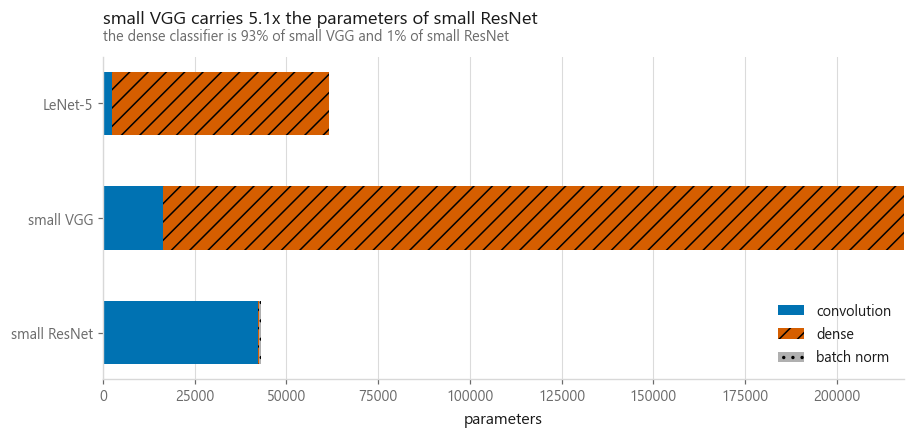

In [8]:
fig, ax = plt.subplots(figsize=(9.4, 3.8))
order = list(split.index)[::-1]
left = np.zeros(len(order))
pieces = [("convolution", style.PALETTE[0], None),
          ("dense", style.HIGHLIGHT, "//"),
          ("batch norm", style.NEUTRAL, "..")]

for column, colour, hatch in pieces:
    values = split.loc[order, column].to_numpy(dtype=float)
    ax.barh(order, values, left=left, color=colour, hatch=hatch,
            label=column, height=0.55)
    left += values

ax.set_xlabel("parameters")
ax.set_xlim(0, None)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.legend(loc="lower right")
heaviest = split["total"].idxmax()
lightest = split["total"].idxmin()
style.title(
    ax,
    f"{heaviest} carries {split.loc[heaviest, 'total'] / split.loc[lightest, 'total']:.1f}x "
    f"the parameters of {lightest}",
    f"the dense classifier is {split.loc[heaviest, 'dense share']:.0%} of {heaviest} and "
    f"{split.loc[lightest, 'dense share']:.0%} of {lightest}")
style.save(fig, FIG / "fig-01-where-the-parameters-live.png")

## 4. How far each one can see

The receptive field is not something to estimate by eye. It falls straight out
of the layer list, so I read the layer list off the built model rather than
retyping it, which means the table cannot drift out of step with the code.

The 1x1 convolutions on the residual shortcuts are excluded. They sit beside the
main path rather than on it, and the reach of a block is set by its longest
route. [08-01](../01-convolution-and-pooling/) checked this recurrence against
autograd on a real network, so I use it here without repeating the check.

In [9]:
def layer_spec(model, skip="shortcut"):
    """(name, kernel, stride, dilation) for every layer that moves a window."""
    spec = []
    for name, m in model.named_modules():
        if skip in name:
            continue
        if isinstance(m, nn.Conv2d):
            spec.append((name, m.kernel_size[0], m.stride[0], m.dilation[0]))
        elif isinstance(m, (nn.MaxPool2d, nn.AvgPool2d)):
            k = m.kernel_size if isinstance(m.kernel_size, int) else m.kernel_size[0]
            s = m.stride if isinstance(m.stride, int) else m.stride[0]
            spec.append((name, k, s, 1))
    return spec


def receptive_field(spec):
    r, j, rows = 1, 1, []
    for name, k, s, d in spec:
        r = r + d * (k - 1) * j
        j = j * s
        rows.append({"layer": name, "kernel": k, "stride": s, "jump": j,
                     "receptive field": r})
    return pd.DataFrame(rows)


fields = {}
for name, builder in MODELS.items():
    model = builder()
    trunk = model.features if isinstance(model.features, nn.Module) else model
    table = receptive_field(layer_spec(trunk if isinstance(trunk, nn.Module) else model))
    fields[name] = table

for name, table in fields.items():
    print(f"\n{name}: {len(table)} layers that move a window, "
          f"final receptive field {table['receptive field'].iloc[-1]} pixels")
    print(table.to_string(index=False))


LeNet-5: 4 layers that move a window, final receptive field 16 pixels
layer  kernel  stride  jump  receptive field
    0       5       1     1                5
    2       2       2     2                6
    3       5       1     2               14
    5       2       2     4               16

small VGG: 6 layers that move a window, final receptive field 16 pixels
layer  kernel  stride  jump  receptive field
    0       3       1     1                3
    2       3       1     1                5
    4       2       2     2                6
    5       3       1     2               10
    7       3       1     2               14
    9       2       2     4               16

small ResNet: 10 layers that move a window, final receptive field 48 pixels
         layer  kernel  stride  jump  receptive field
        stem.0       3       1     1                3
        stem.3       2       2     2                4
stage1.0.conv1       3       1     2                8
stage1.0.conv2       3 

LeNet-5       :  16 pixels, sees a window, never the whole garment


small VGG     :  16 pixels, sees a window, never the whole garment
small ResNet  :  48 pixels, covers the image


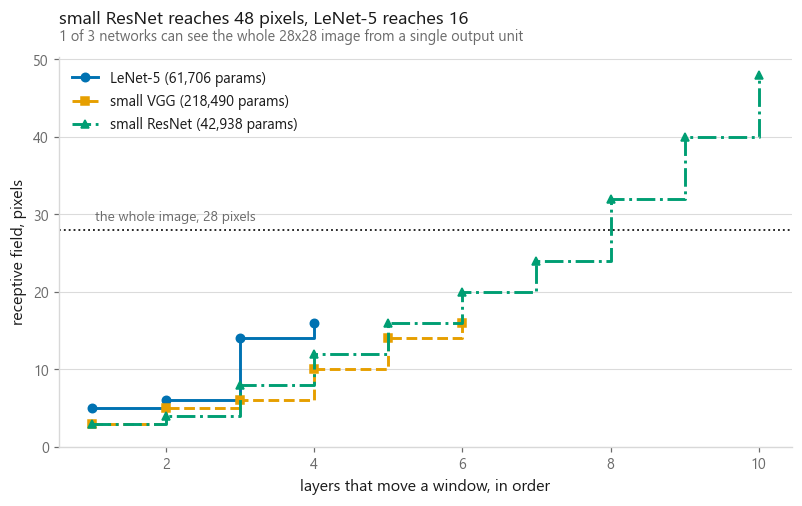

In [10]:
IMAGE = 28
fig, ax = plt.subplots(figsize=(8.6, 4.6))

for i, (name, table) in enumerate(fields.items()):
    steps = np.arange(1, len(table) + 1)
    ax.step(steps, table["receptive field"], where="post",
            color=style.PALETTE[i], ls=style.DASHES[i], marker=style.MARKERS[i],
            label=f"{name} ({count(MODELS[name]()):,} params)")

ax.axhline(IMAGE, color=style.INK, lw=1.2, ls=":")
ax.annotate("the whole image, 28 pixels", xy=(1, IMAGE), xytext=(2, 6),
            textcoords="offset points", fontsize=9, color=style.MUTED)
ax.set_xlabel("layers that move a window, in order")
ax.set_ylabel("receptive field, pixels")
ax.set_ylim(0, None)
ax.legend(loc="upper left")

finals = {name: int(t["receptive field"].iloc[-1]) for name, t in fields.items()}
sees_all = [n for n, v in finals.items() if v >= IMAGE]
style.title(
    ax,
    f"{max(finals, key=finals.get)} reaches {max(finals.values())} pixels, "
    f"{min(finals, key=finals.get)} reaches {min(finals.values())}",
    f"{len(sees_all)} of {len(finals)} networks can see the whole 28x28 image "
    f"from a single output unit")
style.save(fig, FIG / "fig-02-receptive-field.png")

for name, value in finals.items():
    verdict = "covers the image" if value >= IMAGE else "sees a window, never the whole garment"
    print(f"{name:<14}: {value:>3} pixels, {verdict}")

A network whose final feature map cannot see a whole garment is deciding
"sneaker or boot" from a patch. Stride is what buys the reach cheaply: every
pool multiplies the jump, so a convolution placed after two pools advances the
reach four pixels instead of two for exactly the same nine weights.

## 5. Training all three, and the price of the parameters

Identical settings everywhere. Adam at one learning rate, the same batch size,
the same subset, the same seed before each model is built so the initialisation
is reproducible. Nothing is tuned per architecture, which is the only way the
comparison means anything.

I also train LeNet twice, once with its original `tanh` and once with ReLU and
max pooling, because that substitution is the single change with the best claim
to having unlocked everything after it.

In [11]:
def train(model, data_loader, epochs=EPOCHS, lr=LR, track_grad=False):
    """One training run. Returns the model, a per-epoch frame, and first-layer grads."""
    model = model.to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    rows, first_grads = [], []

    for epoch in range(1, epochs + 1):
        sync()
        started = time.perf_counter()
        model.train()
        run_loss = correct = seen = 0

        for xb, yb in data_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimiser.zero_grad(set_to_none=True)
            out = model(xb)
            loss = F.cross_entropy(out, yb)
            loss.backward()
            if track_grad and epoch == 1:
                # read the gradient before the optimiser step consumes it
                first_grads.append(float(model.first_conv.weight.grad.norm()))
            optimiser.step()

            run_loss += float(loss) * len(yb)
            correct += int((out.argmax(1) == yb).sum())
            seen += len(yb)

        sync()
        rows.append({"epoch": epoch, "loss": run_loss / seen,
                     "running accuracy": correct / seen,
                     "seconds": time.perf_counter() - started})

    return model, pd.DataFrame(rows), first_grads


@torch.no_grad()
def accuracy(model, data_loader):
    """Accuracy in eval mode, which matters the moment batch norm is involved."""
    model.eval()
    correct = total = 0
    for xb, yb in data_loader:
        xb, yb = xb.to(device), yb.to(device)
        correct += int((model(xb).argmax(1) == yb).sum())
        total += len(yb)
    return correct / total

In [12]:
def lenet_relu():
    """LeNet's skeleton with the two substitutions that came later."""
    model = LeNet5(activation=nn.ReLU)
    model.features[2] = nn.MaxPool2d(2)
    model.features[5] = nn.MaxPool2d(2)
    return model


runs = {
    "LeNet-5": LeNet5,
    "LeNet, ReLU + max pool": lenet_relu,
    "small VGG": SmallVGG,
    "small ResNet": SmallResNet,
}

results, histories, trained = [], {}, {}
for name, builder in runs.items():
    torch.manual_seed(SEED)
    model, history, _ = train(builder(), train_loader)
    trained[name] = model
    histories[name] = history
    results.append({
        "model": name,
        "parameters": count(model),
        "train accuracy": accuracy(model, train_eval_loader),
        "test accuracy": accuracy(model, test_loader),
        "seconds per epoch": history["seconds"].mean(),
    })
    print(f"{name:<24} done in {history['seconds'].sum():5.1f} s")

scores = pd.DataFrame(results)
scores["gap"] = scores["train accuracy"] - scores["test accuracy"]
scores["test error"] = 1 - scores["test accuracy"]

print()
print(scores.to_string(index=False, formatters={
    "parameters": "{:,}".format,
    "train accuracy": "{:.4f}".format,
    "test accuracy": "{:.4f}".format,
    "seconds per epoch": "{:.1f}".format,
    "gap": "{:+.4f}".format,
    "test error": "{:.4f}".format,
}))

# a binomial standard error on the test set, as a yardstick for the differences above
best = scores.loc[scores["test accuracy"].idxmax()]
se = float(np.sqrt(best["test accuracy"] * (1 - best["test accuracy"]) / len(y_test)))
print(f"\nstandard error on a test accuracy of {best['test accuracy']:.4f} "
      f"over {len(y_test):,} images: {se:.4f}")

ranked = scores.sort_values("test accuracy", ascending=False).reset_index(drop=True)
top_gap = ranked.loc[0, "test accuracy"] - ranked.loc[1, "test accuracy"]
print(f"top two: {ranked.loc[0, 'model']} and {ranked.loc[1, 'model']}, "
      f"{top_gap:.4f} apart, which is {top_gap / se:.1f} standard errors")
print("separable" if top_gap > 2 * se
      else "not separable, so treat the top two as tied")

# The result I did not expect. Modernising LeNet's tanh and average pooling is
# supposed to be a free win, and here it went the other way by enough to matter.
lenet_change = (scores.loc[1, "test accuracy"] - scores.loc[0, "test accuracy"])
print(f"\nLeNet with ReLU and max pooling, against the original: "
      f"{lenet_change:+.4f} ({lenet_change / se:+.1f} standard errors)")

C:\Users\pilot\AppData\Local\Temp\ipykernel_33316\4134983859.py:24: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  run_loss += float(loss) * len(yb)


LeNet-5                  done in   2.5 s


LeNet, ReLU + max pool   done in   2.1 s


small VGG                done in   2.4 s


small ResNet             done in   4.3 s

                 model parameters train accuracy test accuracy seconds per epoch     gap test error
               LeNet-5     61,706         0.8086        0.7918               0.5 +0.0168     0.2082
LeNet, ReLU + max pool     61,706         0.7795        0.7710               0.4 +0.0085     0.2290
             small VGG    218,490         0.8399        0.8310               0.5 +0.0089     0.1690
          small ResNet     42,938         0.8536        0.8231               0.9 +0.0305     0.1769

standard error on a test accuracy of 0.8310 over 10,000 images: 0.0037
top two: small VGG and small ResNet, 0.0079 apart, which is 2.1 standard errors
separable

LeNet with ReLU and max pooling, against the original: -0.0208 (-5.6 standard errors)


accuracy above the weakest model, per ten thousand parameters:
  LeNet-5                  +0.00337
  LeNet, ReLU + max pool   +0.00000
  small VGG                +0.00275
  small ResNet             +0.01213


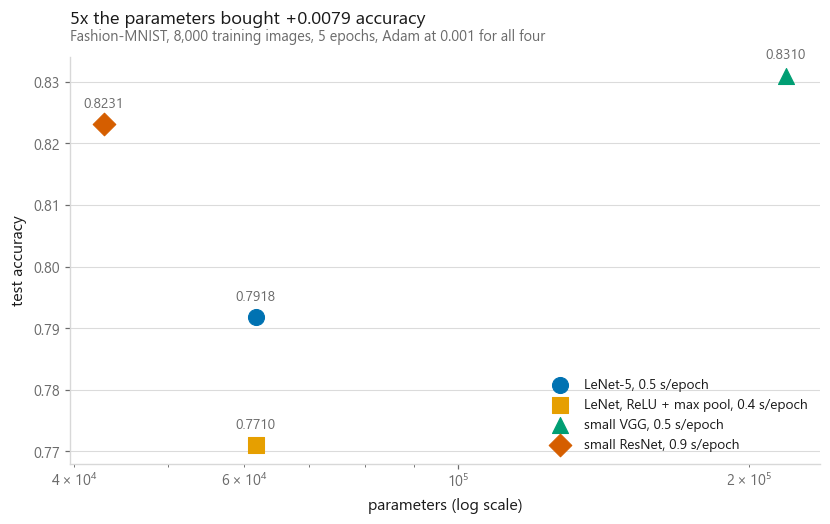

In [13]:
fig, ax = plt.subplots(figsize=(8.8, 4.8))
for i, row in scores.iterrows():
    ax.scatter(row["parameters"], row["test accuracy"], s=110,
               color=style.PALETTE[i], marker=style.MARKERS[i], zorder=3,
               label=f"{row['model']}, {row['seconds per epoch']:.1f} s/epoch")
    ax.annotate(f"{row['test accuracy']:.4f}",
                xy=(row["parameters"], row["test accuracy"]),
                xytext=(0, 11), textcoords="offset points",
                ha="center", fontsize=9, color=style.MUTED)

ax.set_xscale("log")
ax.set_xlabel("parameters (log scale)")
ax.set_ylabel("test accuracy")
ax.legend(loc="lower right", fontsize=9)

biggest = scores.loc[scores["parameters"].idxmax()]
smallest = scores.loc[scores["parameters"].idxmin()]
style.title(
    ax,
    f"{biggest['parameters'] / smallest['parameters']:.0f}x the parameters bought "
    f"{biggest['test accuracy'] - smallest['test accuracy']:+.4f} accuracy",
    f"Fashion-MNIST, {N_TRAIN:,} training images, {EPOCHS} epochs, Adam at {LR:g} for all four")
style.save(fig, FIG / "fig-03-parameters-vs-accuracy.png")

per_10k = (scores["test accuracy"] - scores["test accuracy"].min()) / (scores["parameters"] / 1e4)
print("accuracy above the weakest model, per ten thousand parameters:")
for name, value in zip(scores["model"], per_10k):
    print(f"  {name:<24} {value:+.5f}")

Three things to read off that chart, and one of them is a result I did not
expect.

The first is the horizontal axis. Parameter count and accuracy are not the same
quantity and the gap between them is the entire argument for architecture as a
subject. A design that spends its weights on a dense classifier over a 7x7 map
is spending them on position-specific bookkeeping. Note also what the printed
comparison of the top two says: the two best models are close enough that this
test set does not separate them, so the ranking is between families, not between
the first and second row of it.

The second is the seconds-per-epoch figure in the legend. Parameters are not
cost. A dense layer holds a great many weights and touches each one once per
image; a convolution holds few and touches each one at every position, so the
arithmetic bill follows the feature map size, not the parameter count. The two
columns disagree, and the table above is where you can see by how much.

The third is the pair of LeNets, and it went the wrong way. I put ReLU and max
pooling into LeNet expecting the free win everyone describes, and the printed
line says it lost by several standard errors. That is large enough to need an
explanation rather than a shrug.

The standard result is real and I am not disputing it. What ReLU fixes is
saturation: `tanh` flattens out at both ends, its derivative goes to zero there,
and in a deep stack that shrinks the gradient multiplicatively with depth. That
is a statement about depth. LeNet is four layers deep with a 16-pixel receptive
field, and four `tanh` layers do not have a vanishing gradient problem. The fix
is aimed at a disease this patient does not have.

Two things then push the other way at this scale. ReLU sets roughly half its
activations to exactly zero, which is cheap when a layer has hundreds of
channels and expensive when the first convolution has six. And max pooling keeps
one pixel in four while average pooling keeps a summary of all four, which suits
a smooth greyscale silhouette where the informative signal is the shape of a
region rather than the location of the brightest edge in it.

So the conditional version is the useful one. ReLU and max pooling are what
makes depth possible, and their advantage grows with depth, channel width and
input size. On a four-layer network over 28x28 greyscale they are not free, and
swapping them in because a later architecture did is cargo cult. The place to
see them earn their keep is the 25-layer stack in section 6, where the plain
`tanh` version would not train at all.

## 6. The reason ResNet exists

Now the experiment the chapter was written for. I want a stack where the only
thing that changes is depth, and a second stack identical to the first except
for one addition sign.

In [14]:
class Block(nn.Module):
    """Two 3x3 convolutions. The `residual` switch adds the input back, and that
    is the only difference between the two families compared below. Parameter
    counts are identical either way."""

    def __init__(self, channels, residual, norm=True):
        super().__init__()
        make_norm = (lambda: nn.BatchNorm2d(channels)) if norm else (lambda: nn.Identity())
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, bias=not norm)
        self.norm1 = make_norm()
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=not norm)
        self.norm2 = make_norm()
        self.residual = residual

    def forward(self, x):
        out = F.relu(self.norm1(self.conv1(x)))
        out = self.norm2(self.conv2(out))
        if self.residual:
            out = out + x
        return F.relu(out)


class Stack(nn.Module):
    """A stem, `n_blocks` identical blocks, global average pool, linear head.

    Deliberately narrow and run at 7x7, so depth is affordable and is the only
    thing moving. This is a probe, not a competitive classifier.
    """

    def __init__(self, n_blocks, residual, norm=True, width=16, n_classes=10):
        super().__init__()
        self.stem = nn.Conv2d(1, width, 3, stride=2, padding=1, bias=not norm)  # 28 -> 14
        self.stem_norm = nn.BatchNorm2d(width) if norm else nn.Identity()
        self.stem_pool = nn.MaxPool2d(2)                                        # 14 -> 7
        self.blocks = nn.Sequential(*[Block(width, residual, norm) for _ in range(n_blocks)])
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Linear(width, n_classes)
        self.first_conv = self.stem
        self.conv_layers = 1 + 2 * n_blocks

    def forward(self, x):
        x = self.stem_pool(F.relu(self.stem_norm(self.stem(x))))
        x = self.blocks(x)
        return self.head(torch.flatten(self.pool(x), 1))


def he_init(model):
    """Kaiming normal on every convolution.

    PyTorch's default convolution initialisation is a Kaiming uniform with a gain
    meant for leaky ReLU, which shrinks the activation variance at every layer. It
    is fine for a six-layer network and ruinous for a sixty-layer one, and one of
    the families below is left on the default on purpose so you can see that.
    """
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    return model


plain_probe = Stack(4, residual=False)
res_probe = Stack(4, residual=True)
print(f"plain stack, 4 blocks    : {count(plain_probe):,} parameters")
print(f"residual stack, 4 blocks : {count(res_probe):,} parameters")
print(f"identical: {count(plain_probe) == count(res_probe)}")
print("The skip connection costs nothing. It is an addition, not a layer.")

plain stack, 4 blocks    : 19,034 parameters
residual stack, 4 blocks : 19,034 parameters
identical: True
The skip connection costs nothing. It is an addition, not a layer.


### What arrives at the first layer, before any training

This measurement is nearly free and it is the most direct evidence in the
chapter. Build a stack at a given depth, push one batch through it, call
`backward` once, and read the norm of the gradient sitting on the first
convolution's weights. No training, no tuning, nothing to argue about.

Four families. Plain with PyTorch's default initialisation, plain with He
initialisation, plain with He and batch norm, and residual with He and batch
norm. Reading them in that order separates three different fixes that are often
credited to each other.

I also print the standard deviation of the logits at initialisation. If the
forward signal has collapsed, every image gets the same ten numbers, the loss
sits exactly at the natural logarithm of the class count, and the network is
untrainable before the first step.

In [15]:
PROBE_BLOCKS = [2, 4, 8, 16, 32]
probe_x = x_train[:BATCH].to(device)
probe_y = y_train[:BATCH].to(device)

FAMILIES = [
    ("plain, default init", False, False, False),
    ("plain, He init", False, False, True),
    ("plain, He init + batch norm", False, True, True),
    ("residual, He init + batch norm", True, True, True),
]

rows = []
for label, residual, norm, he in FAMILIES:
    for blocks in PROBE_BLOCKS:
        torch.manual_seed(SEED)
        model = Stack(blocks, residual=residual, norm=norm).to(device)
        if he:
            he_init(model)
        logits = model(probe_x)
        loss = F.cross_entropy(logits, probe_y)
        loss.backward()
        rows.append({
            "family": label,
            "conv layers": model.conv_layers,
            "logit std": float(logits.std()),
            "first-layer grad": float(model.first_conv.weight.grad.norm()),
            "loss at init": float(loss),
        })

grads = pd.DataFrame(rows)
print(f"a network that outputs the same thing for every image has loss "
      f"ln(10) = {np.log(10):.4f}\n")
print(grads.pivot(index="conv layers", columns="family", values="first-layer grad")
      .to_string(float_format="{:.3e}".format))
print("\nstandard deviation of the logits at initialisation")
print(grads.pivot(index="conv layers", columns="family", values="logit std")
      .to_string(float_format="{:.3e}".format))

a network that outputs the same thing for every image has loss ln(10) = 2.3026

family       plain, He init  plain, He init + batch norm  plain, default init  residual, He init + batch norm
conv layers                                                                                                  
5                 1.064e-01                    1.805e-01            7.928e-04                       4.711e-01
9                 1.810e-02                    2.887e-01            1.183e-05                       4.428e-01
17                8.048e-03                    9.482e-01            6.907e-09                       6.726e-01
33                2.728e-03                    1.089e+01            4.485e-15                       1.469e+00
65                4.705e-04                    4.013e+02            0.000e+00                       3.778e+00

standard deviation of the logits at initialisation
family       plain, He init  plain, He init + batch norm  plain, default init  residual, He init +

at 65 convolutional layers:
  plain, default init              0.000e+00
  plain, He init                   4.705e-04
  plain, He init + batch norm      4.013e+02
  residual, He init + batch norm   3.778e+00

smallest: plain, default init (vanished)
largest : plain, He init + batch norm (which is the other failure, not the fix)
change from 5 to 65 layers, per family:
  plain, default init              7.928e-04 -> 0.000e+00   underflowed to zero
  plain, He init                   1.064e-01 -> 4.705e-04   4.4e-03x
  plain, He init + batch norm      1.805e-01 -> 4.013e+02   2.2e+03x
  residual, He init + batch norm   4.711e-01 -> 3.778e+00   8.0e+00x


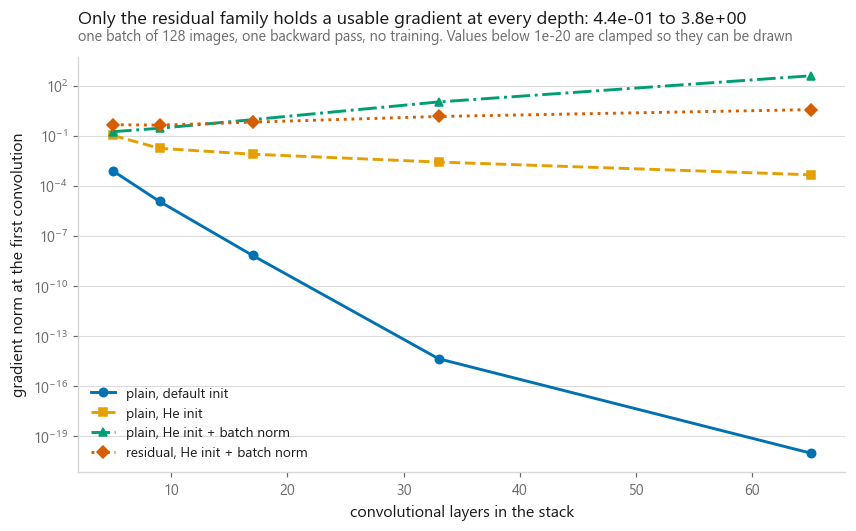

In [16]:
FLOOR = 1e-20
fig, ax = plt.subplots(figsize=(9.0, 4.9))

for i, (label, _, _, _) in enumerate(FAMILIES):
    part = grads[grads["family"] == label]
    ax.plot(part["conv layers"], np.maximum(part["first-layer grad"], FLOOR),
            color=style.PALETTE[i], ls=style.DASHES[i], marker=style.MARKERS[i],
            label=label)

ax.set_yscale("log")
ax.set_xlabel("convolutional layers in the stack")
ax.set_ylabel("gradient norm at the first convolution")
ax.legend(loc="lower left", fontsize=9)

deepest = grads["conv layers"].max()
shallowest_probe = grads["conv layers"].min()
at_depth = grads[grads["conv layers"] == deepest].set_index("family")["first-layer grad"]

# "Largest gradient" is not "best setup". Both failure modes live at the extremes
# of this column, so the summary has to name the family that stays in the middle
# rather than the family at the top.
RESIDUAL = "residual, He init + batch norm"
residual_track = grads[grads["family"] == RESIDUAL]["first-layer grad"]
style.title(
    ax,
    f"Only the residual family holds a usable gradient at every depth: "
    f"{residual_track.min():.1e} to {residual_track.max():.1e}",
    f"one batch of {BATCH} images, one backward pass, no training. "
    f"Values below {FLOOR:g} are clamped so they can be drawn")
style.save(fig, FIG / "fig-04-gradient-at-the-first-layer.png")

print(f"at {deepest} convolutional layers:")
for family, value in at_depth.items():
    print(f"  {family:<32} {value:.3e}")
print(f"\nsmallest: {at_depth.idxmin()} (vanished)")
print(f"largest : {at_depth.idxmax()} (which is the other failure, not the fix)")
print(f"change from {shallowest_probe} to {deepest} layers, per family:")
for label, _, _, _ in FAMILIES:
    track = grads[grads["family"] == label].sort_values("conv layers")["first-layer grad"]
    lo, hi = track.iloc[0], track.iloc[-1]
    ratio = "underflowed to zero" if hi == 0 else f"{hi / lo:.1e}x"
    print(f"  {label:<32} {lo:.3e} -> {hi:.3e}   {ratio}")

Three separate stories in one table, and the order of the columns is what
separates them.

PyTorch's default convolution initialisation, which is not He, underflows to
exactly zero. He initialisation alone slows the decay by orders of magnitude and
does not stop it, because it fixes the variance at layer one and the product
over layers still drifts. Batch norm stops the vanishing outright and overshoots
into the opposite failure: the largest number in the table is not the best setup
in it, and a gradient two orders of magnitude above everyone else's is a network
about to take a wild first step.

The residual family is the only one that stays inside a usable band from the
shallowest probe to the deepest, which is what the identity term in the product
predicts. That term does not grow or shrink with depth, so it puts a floor and a
ceiling on the whole expression.

One diagnostic worth stealing. The logit standard deviations printed underneath
barely move for the family whose gradient went to zero. The forward pass looked
healthy the entire time the backward pass was dead, so a sane-looking activation
histogram is not evidence that a deep network can train.

### Training the two stacks at increasing depth

The gradient measurement above is about initialisation. The claim in the ResNet
paper is stronger and about training: past some depth, the deeper plain network
reaches a **worse training error** than the shallower one, which cannot be
overfitting and cannot be a capacity limit.

So the column to watch below is training accuracy, not test accuracy. Both
families keep batch norm and He initialisation, so the only difference left is
the addition sign inside the block. Every run gets the same subset, the same
number of epochs and the same seed.

The honest caveat first, because it decides how much the result is worth. The
original degradation was demonstrated at tens of layers on a larger dataset with
a long schedule. What I can afford here is a short schedule at modest depth. If
degradation does not appear at these depths, that is a fact about the depths I
could reach, not a refutation, and the printed verdict below says which way it
went rather than my guessing in advance.

In [17]:
DEPTH_BLOCKS = [4, 8, 12]        # 9, 17 and 25 convolutional layers
DEPTH_EPOCHS = 4

depth_rows = []
for blocks in DEPTH_BLOCKS:
    for residual in [False, True]:
        torch.manual_seed(SEED)
        model = he_init(Stack(blocks, residual=residual, norm=True))
        layers = model.conv_layers
        model, history, first_grads = train(model, train_loader,
                                            epochs=DEPTH_EPOCHS, track_grad=True)
        depth_rows.append({
            "conv layers": layers,
            "stack": "residual" if residual else "plain",
            "parameters": count(model),
            "final loss": history["loss"].iloc[-1],
            "train accuracy": accuracy(model, train_eval_loader),
            "test accuracy": accuracy(model, test_loader),
            "mean first-layer grad, epoch 1": float(np.mean(first_grads)),
            "seconds": history["seconds"].sum(),
        })
        print(f"{layers:>3} conv layers, {depth_rows[-1]['stack']:<8} "
              f"train {depth_rows[-1]['train accuracy']:.4f}  "
              f"test {depth_rows[-1]['test accuracy']:.4f}  "
              f"{depth_rows[-1]['seconds']:.1f} s")

depth = pd.DataFrame(depth_rows)
print()
print(depth.to_string(index=False, formatters={
    "parameters": "{:,}".format,
    "final loss": "{:.4f}".format,
    "train accuracy": "{:.4f}".format,
    "test accuracy": "{:.4f}".format,
    "mean first-layer grad, epoch 1": "{:.3e}".format,
    "seconds": "{:.1f}".format,
}))

  9 conv layers, plain    train 0.7686  test 0.7578  3.0 s


  9 conv layers, residual train 0.7542  test 0.7415  3.4 s


 17 conv layers, plain    train 0.7331  test 0.7066  5.3 s


 17 conv layers, residual train 0.8327  test 0.8117  4.3 s


 25 conv layers, plain    train 0.6142  test 0.5993  5.2 s


 25 conv layers, residual train 0.8107  test 0.7697  5.5 s

 conv layers    stack parameters final loss train accuracy test accuracy mean first-layer grad, epoch 1 seconds
           9    plain     19,034     0.8216         0.7686        0.7578                      2.398e-01     3.0
           9 residual     19,034     0.6655         0.7542        0.7415                      3.850e-01     3.4
          17    plain     37,722     0.8324         0.7331        0.7066                      6.908e-01     5.3
          17 residual     37,722     0.5250         0.8327        0.8117                      5.850e-01     4.3
          25    plain     56,410     1.1936         0.6142        0.5993                      2.361e+00     5.2
          25 residual     56,410     0.4963         0.8107        0.7697                      6.989e-01     5.5


In [18]:
train_by_depth = depth.pivot(index="conv layers", columns="stack", values="train accuracy")
test_by_depth = depth.pivot(index="conv layers", columns="stack", values="test accuracy")

shallowest, deepest_trained = train_by_depth.index.min(), train_by_depth.index.max()
plain_change = train_by_depth.loc[deepest_trained, "plain"] - train_by_depth.loc[shallowest, "plain"]
res_change = train_by_depth.loc[deepest_trained, "residual"] - train_by_depth.loc[shallowest, "residual"]
skip_gain = (train_by_depth["residual"] - train_by_depth["plain"]).loc[deepest_trained]

if plain_change < -0.005:
    verdict = "the plain stack got WORSE on the training set as it got deeper, which is the degradation ResNet was built for"
elif plain_change < 0.005:
    verdict = "the plain stack stopped improving with depth but did not clearly degrade at these depths"
else:
    verdict = "the plain stack kept improving with depth, so no degradation appeared at the depths I could afford"

print(f"plain stack, training accuracy from {shallowest} to {deepest_trained} layers   : {plain_change:+.4f}")
print(f"residual stack, training accuracy over the same range   : {res_change:+.4f}")
print(f"skip connections were worth {skip_gain:+.4f} training accuracy at {deepest_trained} layers")
print(f"\nverdict: {verdict}")

grad_by_depth = depth.pivot(index="conv layers", columns="stack",
                            values="mean first-layer grad, epoch 1")
print("\nmean gradient norm at the first convolution during the first epoch")
print(grad_by_depth.to_string(float_format="{:.3e}".format))

plain stack, training accuracy from 9 to 25 layers   : -0.1544
residual stack, training accuracy over the same range   : +0.0565
skip connections were worth +0.1965 training accuracy at 25 layers

verdict: the plain stack got WORSE on the training set as it got deeper, which is the degradation ResNet was built for

mean gradient norm at the first convolution during the first epoch
stack           plain  residual
conv layers                    
9           2.398e-01 3.850e-01
17          6.908e-01 5.850e-01
25          2.361e+00 6.989e-01


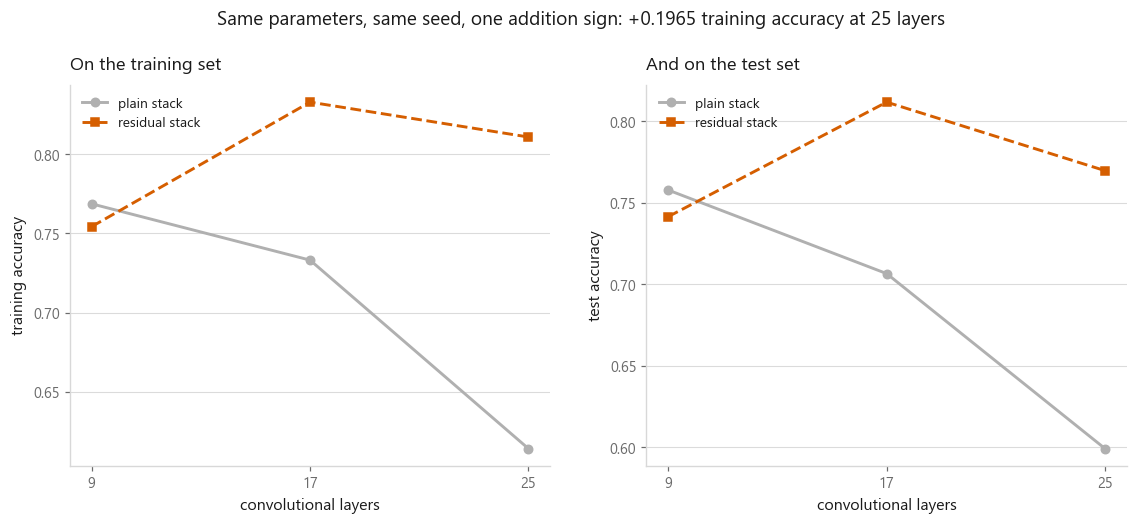

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.5))
panels = [(train_by_depth, "training accuracy", "On the training set"),
          (test_by_depth, "test accuracy", "And on the test set")]

for ax, (table, ylabel, headline) in zip(axes, panels):
    for i, column in enumerate(["plain", "residual"]):
        ax.plot(table.index, table[column],
                color=[style.NEUTRAL, style.HIGHLIGHT][i], ls=style.DASHES[i],
                marker=style.MARKERS[i], label=f"{column} stack")
    ax.set_xlabel("convolutional layers")
    ax.set_ylabel(ylabel)
    ax.set_xticks(list(table.index))
    ax.legend(loc="best", fontsize=9)
    style.title(ax, headline)

fig.suptitle(
    f"Same parameters, same seed, one addition sign: {skip_gain:+.4f} training accuracy "
    f"at {deepest_trained} layers",
    x=0.5, y=1.03, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-05-depth-plain-vs-residual.png")

### Reading that honestly

Three separate things could be true of the numbers above, and they call for
different conclusions, so it is worth saying which is which before looking.

If the plain stack's **training** accuracy falls as depth rises, that is
degradation and the skip connection is fixing exactly what it was designed to
fix. If the plain stack merely stops improving while the residual one keeps
going, the mechanism is visible but milder than the paper's headline, which is
the expected outcome at this depth and this budget. If both improve equally,
then the depths reached here were not deep enough to hurt, and the evidence for
the skip connection in this notebook is the initialisation measurement in the
previous section rather than this one.

I expected the gradient table under the sweep to supply the mechanism, on the
usual reasoning that the plain stack fails because less signal reaches its first
layer. Read the table before accepting that. At the greatest depth here the
plain stack, the one whose training accuracy fell, received a **larger** first
layer gradient than the residual stack that kept improving, and the ordering
between them changes sign partway down the column.

So this notebook measures the degradation and does not explain it. Vanishing
gradients are a real phenomenon and the initialisation section above shows them
directly, at depths well past anything in this sweep. They are not what is
happening in these rows. A large gradient at the first layer is not the same as
a useful one, and nothing here measures whether the update it produced pointed
anywhere good.

Reporting the ablation and calling the gradient column its cause would have been
the easy version of this section. The two measurements disagree, so both are
printed.

One more caveat that applies to every row. These are single-seed runs on a small
subset, and the standard error on the test accuracies was printed in section 5.
Differences smaller than that are not differences.

In [20]:
print(f"whole notebook: {(time.perf_counter() - NOTEBOOK_STARTED) / 60:.1f} minutes on {device}")

whole notebook: 0.8 minutes on cuda


## Cheat sheet

| | |
|---|---|
| **LeNet-5** | Conv, pool, conv, pool, dense. Still the skeleton. Its dense head holds most of its weights |
| **VGG** | Only 3x3 convolutions and 2x2 pools, depth as the single dial. Simple to read, expensive to run |
| **Why 3x3** | Two of them reach as far as one 5x5 with fewer weights and one extra nonlinearity. Three match a 7x7 |
| **ResNet** | `y = relu(F(x) + x)`. The addition costs no parameters and puts an identity term in the gradient product |
| **Global average pooling** | Replaces the flatten. Deletes the largest parameter block in the other two architectures |
| **Receptive field** | `r += d(k-1)*jump` then `jump *= stride`. Compute it; a network that cannot see the object is guessing from a patch |
| **Parameters are not cost** | Convolutions reuse each weight at every position, so seconds per epoch tracks feature map size, not weight count |
| **Watch out** | The default convolution initialisation in PyTorch is not He. It is fine shallow and it is not fine deep |
| **Next** | [08-04 Data augmentation](../04-data-augmentation/), which buys accuracy without touching the architecture at all |

## What to remember

1. LeNet fixed the shape, VGG fixed the kernel, ResNet fixed the optimisation.
   Each was a response to a specific problem, and each is worth learning as the
   answer to that problem rather than as a diagram.
2. Stacking 3x3 kernels reaches as far as one large kernel with fewer weights
   and more nonlinearities, and the saving widens as the target reach grows.
   That is arithmetic, so it holds before you train anything.
3. The dense classifier after the flatten is where a VGG-shaped network keeps
   its parameters. Global average pooling removes that block entirely, which is
   why a residual network can be deeper and smaller at the same time.
4. Parameter count is a poor proxy for compute. The seconds-per-epoch column
   disagrees with the parameter column in section 5, and the reason is that a
   convolution reuses each weight at every spatial position.
5. Compute the receptive field. It is four lines of arithmetic off the layer
   list, and it tells you whether the last feature map can see the object at all.
6. The skip connection adds no parameters. Identical counts were printed for the
   plain and residual stacks in section 6.
7. Degradation is a claim about training error, not test error. If a deeper
   network fits the training set worse than a shallower one, the problem is
   optimisation, and no amount of regularisation will help.
8. Initialisation, normalisation and skip connections are three different fixes
   to related problems. The gradient sweep separates them, and the family left on
   PyTorch's default initialisation is there to show what one wrong default does
   to a deep stack.
9. A fix aimed at depth does not pay at four layers. Replacing LeNet's tanh and
   average pooling with ReLU and max pooling made it measurably worse here,
   because saturation is not what limits a four-layer network and ReLU zeroing
   half of six channels is a real loss. Adopt a modernisation when your network
   has the problem it solves, not because a later architecture used it.

The next chapter, [08-04 Data augmentation](../04-data-augmentation/), goes after
accuracy without touching the architecture, and finds that the standard advice
there does not survive measurement either.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [08-04 Data augmentation](../04-data-augmentation/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#DeepLearning` `#CNN` `#ResNet` `#VGG` `#LeNet` `#ComputerVision` `#PyTorch`
`#FashionMNIST` `#MachineLearning` `#MLTutorial` `#LearnMachineLearning` `#AI`